# Notebook for analyzing redunancy plateaus - Figure 6

This notebook is aimed at being an interactive and pedagogic way of examining the numerics of the paper. Each step is explained in short, noting that techincal details should be sought from the paper itself. If the contents here seem too techincal or hard to grasp, you can find an easier example utilising $\texttt{QuTiP}$ for a more simple Petz recovery example in the attached supplementary material. Here, we follow section 4 - Numerical analysis from the paper itself, while naturally using many of the results presented earlier in the paper! 


### Recreating results


To recreate results shown in the paper / in the results directory of this repository, we have provided separate notebooks for each figure for ease of use. As a reminder, here are the details shared between all figures:

1. All coupling constant are fixed as $g_l=g=1.0$
2. Initial states of the apparatus are all $\ket{+}$ so $\ket{\Xi^R}=\ket{+}^{\otimes N}$, with $N=10$
3. Times to consider are from $t_i=0$ to the final time $t_f=\pi / 4g$

One can find further details on each figure in the paper, but the key differences require only a slight change of variables.

### Importing necessary packages and utility functions

Instead of writing every bit of code ourselves, the use of existing, excellent libraries is preferrable. This notebook, moreover, all the numerics of the project are mostly dependent on QuTiP - Quantum Toolbox in Python. Additionally, common but very useful libraries such as NumPy are used along with the associated dependencies of these libraries. To install these libraries, there are brief instructions attached to the readme-file. If these do not illuminate what to do, there are more extensive versions in the documentation directory!

In [1]:
# library imports
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import plasma

# local file imports
import sys
import os
sys.path.append(os.path.abspath(".."))

import src.utility_functions as utils
import src.recovery_utilities as rec

### Create one-to-all system and prepare following steps (section 3A, eqs. 32 & 33)

Initialize all $N+1$ qubits for the one-to-all system, and prepare suitable states for $\Gamma$ and the total state of $\Xi$. The system's initial state is prepared with the basis $\{\ket{r}\}=\{\ket{0},\ket{1}\}$, which diagonalises the system's part of the interaction Hamiltonian. To realise this in practice, we use the bloch vector in spherical coordinates to quickly input any possible qubit state, such that

$$
x_\Gamma=\frac{1}{2}(\mathbb I+\vec{a}\cdot\vec{\sigma})~~,~\vec{a}=(r\sin\theta\cos\phi,~r\sin\theta\sin\phi,~r\cos\theta)~.
$$

This is not explicitly used in the paper, but one can see that this is just a way to dictate the coefficients $\gamma_{rr'}$ appearing in the general form $x_{\Gamma}=\sum_{r,r'}\gamma_{rr'}\ket{r}\bra{r'}$. The environment/apparatus (the all) starts in a "ready-to-read" state given by 

$$
\ket{\Xi^R}=\bigotimes_{l=1}^N(\alpha_l\ket{0}_l+\beta_l\ket{1}_l)~.
$$

The coefficients $\alpha_l,\beta_l$ are generated such that the resulting single-qubit states are normalized, i.e. valid states. There are many ways to create these states, but we have provided some useful utility functions for pulling the coefficients out of different kinds of distributions.

In [2]:
"""
Define necessary variables for initializing system
"""

N = 10                  # Number of qubits in apparatus
l_low = 0.010           # Ready-to-read state constant lower bound
l_hgh = 0.012           # Ready-to-read state constant higher bound
alpha_l_seed = 6900     # Seed 1 for reproducible constants
beta_l_seed = 4200      # Seed 2 for reproducible constants
array_dist = "uniform"  # What type of distribution you want to pull numbers out of // "uniform", "normal", "gamma"
g_low = 1.0             # Coupling constant array lower bound
g_hgh = 1.15            # Coupling constant array higher bound
g_seed = 1000           # Seed for coupling array

"""
Below is a short example on how to use the arrays for generating
state of the apparatus, if not recreating paper results exactly.
"""

# generate arrays using provided functions
alpha_l = utils.generate_complex_array(n=N, type=array_dist, seed=alpha_l_seed, low_lim=l_low, hgh_lim = l_hgh, order=None)
beta_l = utils.generate_complex_array(n=N, type=array_dist, seed=beta_l_seed, low_lim=l_low, hgh_lim = l_hgh, order=None)

# create the kets of the initial states for apparatus qubits, normalize them with .unit()
example_states = [(alpha_l[i]*basis(2,0) + beta_l[i]*basis(2,1)).unit() for i in range(N)]


# Initialize N qubits of the apparatus in the plus state
init_xi_kets = [(basis(2,0) + basis(2,1)).unit() for i in range(N)]

# Define length, polar angle and azithmutal angle for bloch vector
r = 0.3
theta = 0
phi = 0

# Create initial state of the system as per the definition in the above cell
init_gamma = utils.generate_state_from_coords([r, theta, phi])

# Generate array of coupling constants        g_l between system and apparatus
coupling_array = utils.generate_real_array(n=N, type=array_dist, seed=g_seed, low_lim=g_low, hgh_lim = g_hgh, order="ordered")

# Generate an array of time steps to consider for the encoding and recovery
g = 1.0
times = [i*np.pi/(4*g*N) for i in range(N+1)]

# array of integer values for k, i.e. from 1 to N
k_array = [i for i in range(1, N+1)]

# random number generator
gue_rng = np.random.default_rng(seed=67)

# define which observables for which subsystems of the environment get coupled
xi_observables = [utils.gue_hermitian(2, gue_rng) for _ in range(N)]


### Find encoding map and associated Petz recovery (section 3A, eqs. 34 - 43)

For each state of the apparatus, we generate a unitary for the time evolution of said state according to

$$
    \ket{\Xi^r(t)}=\bigotimes_{l=1}^N U_l^r(t)\ket{\Xi^R}_l=\bigotimes_{l=1}^N\ket{\Xi^r(t)}_l~,
$$
where we define the two unitaries with $r=0,1$ as

$$
    U_l^r(t)=\exp[-i\omega_r g_l O_l t]~.
$$

In cases where the coupling is not $Z-Z$, we can find random hermitian matrices by considering the GUE $(n)$ ensamble to pull these out of. To this end, one can find supplementary functions in the $\texttt{utility\_functions.py}$ file, which is located in the "src" -directory. Details of this, in short, are found in section four of the paper.

In [3]:
"""
Prepare unitaries that evolve the l:th state of the environment according to the paper definition,
which is also provided above!
"""

# A parent list corresponding to each time step to be considered
evolved_apparatus_kets = []

# for each time step, consider N coupling constants and two values of r for a qubit system
for t_step in times:
    
    # nested list with unitaries for all qubits per time step
    kets = []

    for i, g in enumerate(coupling_array):

        # make the two r=0,1 unitaries and add to intermediate list
        r_0 = utils.xi_unitaries(r=0, g_l=g, t=t_step, xi_obs=xi_observables[i], gamma_obs=sigmaz()) #herm_matrices[i]
        r_1 = utils.xi_unitaries(r=1, g_l=g, t=t_step, xi_obs=xi_observables[i], gamma_obs=sigmaz())
        kets.append([r_0 * init_xi_kets[i] , r_1 * init_xi_kets[i]])

    
    # after going through each qubit coupling, add to the main list and go to next step
    evolved_apparatus_kets.append(kets)


Now we need to construct the encoded state $X_{F_k}$ and find the encoding channel via its Kraus operators. The encoded state into a $k$-fragment is defined via the associated encoding channel, such that

$$
    X_{F_k}=\Lambda_k(x_{\Gamma})=\sum_r\gamma_{rr}\bigotimes_{l=1}^k\ket{\Xi^r(t)}_l\bra{\Xi^r(t)}_l~~.
$$

We find the Kraus operators by considering that the action of the encoding channel can be written as 

$$
    \Lambda_k(x_{\Gamma})=\sum_{r}E_k^{(r)}(t)x_{\Gamma}E_k^{(r)\dag}(t)~,~~E_k^{(r)}(t)=\bigotimes_{l=1}^k\ket{\Xi^r(t)}_l\bra{r}~.
$$

The encoded states are needed due to the fact that the Petz later operates on them. But since we have the states $\ket{\Xi^r(t)}_l$, this is not a problem! Even the constants $\gamma_{rr}$ are just the diagonal elements of the initial state of the system, which can be easily extracted with QuTip.

In [4]:
"""
We create the encoded states and Kraus operators in the same loop. To this end,
start by extracting the values of gamma_rr from the initial state of the system
and evolve the states of the enviroment via the unitaries. Once again, to achieve
time dependece explicitly, we consider this process for multiple t_steps.
"""

# Save the system's initial state matrix elements for later
gamma_00, gamma_11 = init_gamma.full()[0][0], init_gamma.full()[1][1]
gamma_01, gamma_10 = init_gamma.full()[0][1], init_gamma.full()[1][0]

# prepare list for encoded states and kraus operators
enc_states = []
kraus_list = []

"""
For each t_step, we need to consider all fragments k. This means that we get 
a data structure consisting of encoded states, which will be something like 
[ (t_1) [state_k=1, state_k=2, ... state_k=N], (t_2) [state_k=1, ...], ... ]

We don't need to loop through the time array explicitly as the evolved state
we created are ordered in the same manner
"""
for state_list in evolved_apparatus_kets:

    # fragment states and operators
    f_states = []
    f_operators = []

    # loop through values of k
    for k in k_array:

        """
        Using the current fragment size k, find the corresponding initial state
        from the list of fragment states created in previous cells and proceed
        to find the corresponding encoding channel + encoded fragment states
        """

        frag_kets = state_list[:k]

        # As we had to cases for r = 0,1, we consider two tensor products
        evolved_r0 = tensor([pair[0] * pair[0].dag() for pair in frag_kets])
        evolved_r1 = tensor([pair[1] * pair[1].dag() for pair in frag_kets])

        # create the two terms in the sum for the encoded fragment state
        r0_term = gamma_00 * evolved_r0
        r1_term = gamma_11 * evolved_r1 

        """
        Add the k:th fragment encoded state to current time step
        list by directly using the above terms in the sum of eq. 48
        """

        fragment_state = r0_term + r1_term
        f_states.append(fragment_state)

        """
        There will be two Kraus operators per each k fragment and naturally,
        k fragments per each time step. These will be with r=0,1
        """

        # Create operators for r = 0 and r = 1
        E_r0 = tensor([pair[0] for pair in frag_kets]) * basis(2,0).dag()
        E_r1 = tensor([pair[1] for pair in frag_kets]) * basis(2,1).dag()


        # append said operators as a pair into the fragments list
        f_operators.append([E_r0, E_r1])


    # after processing all fragments, add the list of those states to the main list of encoded states
    enc_states.append(f_states)
    kraus_list.append(f_operators)


#### (following section 2C, eqs. 10 & 12)

Now, we have the Kraus operators for encoding any initial state of the system into a $k$-fragment in the apparatus. The next step is to construct the adjoint map and inverse square root for the Petz map. The Petz, for a reference state $s$, is defined as 

$$
\mathcal{P}_{\Lambda_k}^s(X_{F_k})=\sqrt{s}\Lambda_k^{\dagger}\left[\Lambda_k(s)^{-1/2}X_{F_k}\Lambda_k(s)^{-1/2}\right]\sqrt{s}~,
$$
where the Petz is a map from the space of density operators of the fragment $F_k$ back to the systems space of density operators, i.e. $\mathcal{P}_{\Lambda_k}^s:~\mathcal{D}(F_k)\rightarrow\mathcal{D}(\Gamma)$. In this case, we fix $s=\mathbb{I}_{\Gamma}/2$, but one can edit the analysis to be with any valid density matrix of the system. The square root and adjoint are trivial with QuTiP's tools but the inverse square root requires a bit of custom work. To this end, let us now construct all these maps and form the Petz with explicit dependence on $t$ and $k$.

Additionally, we compute the fidelity for each time we are considering for $k$-fragments! This is equal to finding the quality $Q(k)$ of recovery one can expect from each fragment size considered for the necessary times.

In [5]:
# Prepare a list which will contain nested lists with recovery fidelities for the time steps for each fragment.
fidelities = []

# Reference state for Petz map, set as the maximally mixed one and its square root
ref = 1/2 * qeye(2)
ref_sqrtm = ref.sqrtm()


# loop through time steps by considering the encoded fragment states
for i, states in enumerate(enc_states):
    
    # list of k fragment Kraus operators for current time step
    tstep_kraus = kraus_list[i]

    # fragment fidelities, i.e. [F_k=1, F_k=2, ..., F_k=N]
    fragment_fidelities = []

    # loop through fragments
    for j, encode_state in enumerate(states):

        # extract pair of Kraus operators
        E_r0, E_r1 = tstep_kraus[j][0], tstep_kraus[j][1]

        """
        Calculate the action of the encoding channel on the
        reference state and take the inverse square root with
        a helper function
        """
        ref_encoded = (E_r0 * ref * E_r0.dag()) + (E_r1 * ref * E_r1.dag())
        ref_encoded_inv = rec.inverse_sqrt_matrix(ref_encoded)

        """
        Find the three parts the Petz is comprised of. One can
        brake it down into what it is inside the square brackets (step 1),
        the adjoint channels action on this (step 2), and finally
        the square roots of the reference on the outside
        """

        step_1 = ref_encoded_inv * encode_state * ref_encoded_inv
        step_2 = (E_r0.dag() * step_1 * E_r0) + (E_r1.dag() * step_1 * E_r1)
        recovered_state = ref_sqrtm * step_2 * ref_sqrtm

        # Find root fidelity between initial state of system and recovered state
        fragment_fidelities.append(fidelity(init_gamma, recovered_state))

    # mutual_infos.append(fragment_mutuals)
    fidelities.append(fragment_fidelities)


### Calculate for redundancy plateuaus (sections 2B, 3A, eqs. 6 - 8)

To look for the main results of the paper, we must look at how mutual information between the initial state of the system and varying sizes of fragment states correspond. Mutual information can be easily computed using the included function in QuTiP, which follow the definition using von Neumann entropies, such that

$$
\mathcal I (x_\Gamma~:~X_{F_k})=S(x_\Gamma)+S(X_{F_k})-S(\rho_{\Gamma\cup F_k}(t))~,
$$

where the joint state of the system and fragment at time $t$ is defined as in the paper

$$
\rho_{\Gamma\cup F_k}(t)=\sum_{r,r'}\gamma_{rr'}\ket{r}\bra{r'}\otimes\ket{\Xi_k^r(t)}\bra{\Xi_k^{r'}(t)}~.
$$

Here, the indice $k$ refers to considering only the corresponding fragment states, i.e.

$$
\ket{\Xi_k^r(t)}=\bigotimes_{l=1}^k U_l^r(t)\ket{\Xi^R}_l=\bigotimes_{l=1}^k\ket{\Xi^r(t)}_l~.
$$

To find the total system of $\Gamma$ and $F_k$ at time $t$, we can directly calculate the terms in the above definition for said total state one by one. This maybe a touch crude but makes the calculation in the program very explicit.

In [6]:
# Define the elements which make up the state of gamma
g_00 = gamma_00 * basis(2,0) * basis(2,0).dag()
g_01 = gamma_01 * basis(2,0) * basis(2,1).dag()
g_10 = gamma_10 * basis(2,1) * basis(2,0).dag()
g_11 = gamma_11 * basis(2,1) * basis(2,1).dag()

"""
Prepare a list to store mutual information per time steps
and for each fragment size. Structure is the same as for previous
datasets.
"""
mutual_infos = []

# Loop through evolved fragment states
for frag_kets in evolved_apparatus_kets:

    # Prepare lists for current time step fragment mutual information values
    frag_mutual_infos = []

    # Calculate each term forming the total evolved state at time t explictly
    evolved_00 = tensor([pair[0] * pair[0].dag() for pair in frag_kets])
    evolved_01 = tensor([pair[0] * pair[1].dag() for pair in frag_kets])
    evolved_10 = tensor([pair[1] * pair[0].dag() for pair in frag_kets])
    evolved_11 = tensor([pair[1] * pair[1].dag() for pair in frag_kets])

    # Form density matrix of system + fragment_k at time t
    total_state_dm = tensor([g_00, evolved_00]) + tensor([g_01, evolved_01]) + tensor([g_10, evolved_10]) + tensor([g_11, evolved_11])

    # compute von neumann entropy of gamma at time t
    gamma_vn = entropy_vn(ptrace(total_state_dm, 0))

    """
    Consider different fragment sizes, use the partial trace
    to disregard everything else in the environment and 
    calculate mutual information between the state of the system and
    the processed environment.
    """
    for k in k_array:

        # Calculate the mutual information between the system and the k:th fragment state at time t
        k_frag_info = gamma_vn + entropy_vn(ptrace(total_state_dm, range(1, k+1))) - entropy_vn(ptrace(total_state_dm, range(0, k+1))) 
        
        # add the resulting value to the list corresponding to current time step
        frag_mutual_infos.append(k_frag_info)

    """
    When all sizes are considered for the current time step, add 
    the intermediary list to the main list and move on
    to the next time step.
    """
    mutual_infos.append(frag_mutual_infos)


### Visualization and analysis (Section 4)

Now that we have all that we want in terms of matching the paper's theoretical part, we move on to analysing the results.

In [7]:
"""
Add zeroes to relevant arrays to showcase the quantum darwinism behaviour explicitly.
One obvious improvement is to implement this seamlessly into the other cells of the notebook
but this way highlights 
"""
for p in range(0, len(fidelities)):
            fidelities[p].insert(0,np.float64(0.0))
            mutual_infos[p].insert(0,np.float64(0.0))

k_array.insert(0, 0.0)

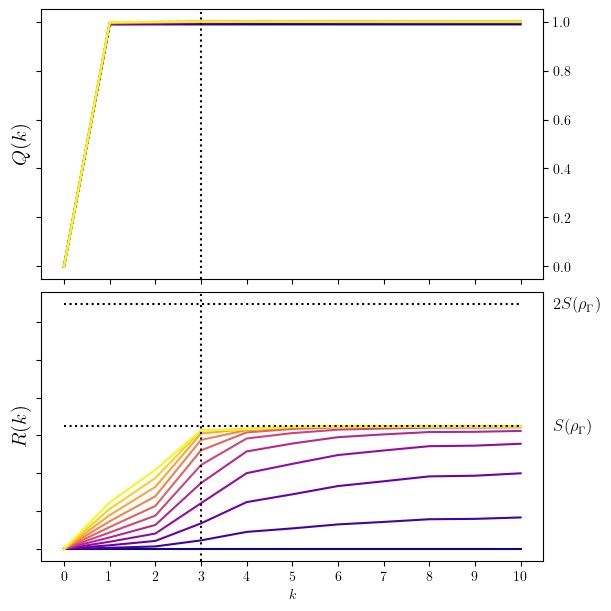

In [9]:
"""
Prepare subplots, one for the quality of recovery (fidelity, top figure)
and one for the mutual information (bottom figure) to analyse 
the appearance of a possible plateau.
"""

# The functions are both as a function k so we can share the vertical axes
fig, (ax, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 6), constrained_layout=True)

# create a color map with len(fidelities) colors
colors = plasma(np.linspace(0, 1, len(fidelities)))

#Font settings to allow for latex in plots
plt.rc('text', usetex = True)
plt.rc('font', family = 'Times New Roman')


"""
As there are two datasets (mutual information & fidelity) both with the same
amount of elements, we need only to loop one and enumerate it to access both
in a convinient way!
"""

# loop over fidelities to access both datasets
for i, dataset in enumerate(fidelities):

    # plot the fidelities (ax) and mutual infos (ax2)
    ax.plot(k_array, dataset, color=colors[i], label=f"Time step = {times[i]}")
    ax2.plot(k_array, mutual_infos[i], color=colors[i], label=f"Time step = {times[i]}")
    

"""
To showcase that the plateuau should manifest around the von Neumann
entropy of the system, we plot a vertical line for this value. Additionally,
we show the bounded nature of the mutual information by plotting its maximum
of 2 * S(Gamma)! One can also choose to add a vertical line at a specified
value to emphasize where the function plateaus. These line are commented out
by default.
"""

ax2.plot(k_array, [gamma_vn] * len(k_array), linestyle="dotted", color="black")
ax2.plot(k_array, [2 * gamma_vn] * len(k_array), linestyle="dotted", color="black")

# Set k0 to be where you detect the plateau
k0 = 3
ax.axvline(k0, linestyle="dotted", color="black")
ax2.axvline(k0, linestyle="dotted", color="black")


"""
Add labels to plots and set ticks to the axes
for easier analysis.
"""

# add LaTeX labels to the right of the second plot for von Neumann entorpy and maximum mutual information
ax2.text(1.02, gamma_vn, r"$S(\rho_\Gamma)$", transform=ax2.get_yaxis_transform(), color="black", va="center", ha="left", fontsize=12)
ax2.text(1.02, 2 * gamma_vn, r"$2S(\rho_\Gamma)$", transform=ax2.get_yaxis_transform(), color="black", va="center", ha="left", fontsize=12)


# Label first y-axis as quality of recovery
ax.set_ylabel(r"$Q(k)$", fontsize = 15)

# Label second y-axis as the R(k) -plateau function as a function of k
ax2.set_xlabel(r"$k$", fontsize = 10)
ax2.set_ylabel(r"$R(k)$", fontsize = 15)

# Tick parameters
ax2.tick_params(axis='y', which='both', labelleft=False)
ax2.set_xticks(ticks=k_array)
ax.yaxis.set_label_position("left")   # label stays on the left
ax.yaxis.tick_right()                 # ticks move to the right
ax.yaxis.set_ticks_position('both')   # ticks on both sides if desired

# Show plot in notebook
plt.show()

# Save the plot as a png with a given name into the "results" 
fig.savefig("../results/fig06_zhcoupling_03.png", dpi=300, bbox_inches="tight")
